In [1]:
import pandas as pd

# Load data
df = pd.read_csv("D:\\New folder\\Cars_data (1).csv")

# Clean numeric columns with commas and strings at the end (e.g., "10,000 km", "15.5 L", "100 bhp")
numeric_cols = ["price", "km_driven", "mileage_new", "max_engine_capacity_new"]
for col in numeric_cols:
    df[col] = (
        df[col]
        .astype(str)  # Ensure all values are strings
        .str.replace(",", "", regex=False)  # Remove commas
        .str.extract(r"([0-9.]+)")  # Extract numeric part using regex
        .squeeze()  # Convert DataFrame to Series if needed
        .astype(float)  # Convert to float
    )

# Verify the cleaned columns
print(df[numeric_cols].head())


      price  km_driven  mileage_new  max_engine_capacity_new
0  950000.0   150000.0        12.99                   2494.0
1  500000.0    53755.0        15.10                   2179.0
2  738000.0    53838.0        18.53                   1199.0
3  850000.0    28112.0        15.80                   1591.0
4  899999.0    63125.0        24.52                   1248.0


In [2]:
# Example: "100.6bhp@3600rpm" → 100.6
df["max_power"] = df["Max Power"].str.extract(r"(\d+\.\d+|\d+)").astype(float)
df["max_torque"] = df["Max Torque"].str.extract(r"(\d+\.\d+|\d+)").astype(float)


In [3]:
# Drop rows with missing price
df.dropna(subset=["price"], inplace=True)

# Fill missing values
df["mileage_new"].fillna(df["mileage_new"].median())

0        12.99
1        15.10
2        18.53
3        15.80
4        24.52
         ...  
34028    17.42
34029    27.39
34030    18.60
34031    18.60
34032    21.21
Name: mileage_new, Length: 34033, dtype: float64

In [4]:
df["max_power"].fillna(df["max_power"].median())
df["max_torque"].fillna(df["max_torque"].median())

0        200.0
1        330.0
2        113.0
3        151.0
4        200.0
         ...  
34028    320.0
34029    190.0
34030    114.7
34031    114.7
34032    113.0
Name: max_torque, Length: 34033, dtype: float64

In [5]:
# Remove rows where 'max_engine_capacity_new' is equal to 0
df = df[df['max_engine_capacity_new'] != 0]

In [6]:
import numpy as np

# Define columns to check for outliers
log_cols = ['max_power', 'max_torque', 'max_engine_capacity_new', 'price']

# For each column, remove rows where the value is outside 1.5*IQR from Q1 or Q3
for col in log_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]

In [7]:
import numpy as np

df["log_max_power"] = np.log(df["max_power"])
df["log_max_torque"] = np.log(df["max_torque"])
df["log_max_engine_capacity_new"] = np.log(df["max_engine_capacity_new"])


In [8]:
import numpy as np

features = [
    
 "km_driven", "mileage_new", 
    "log_max_power", "log_max_torque", "price",
 "log_max_engine_capacity_new"

]

df = df.dropna(subset=["price"])
df = df.dropna(subset=features)
X = df[features]
y = df["price"]
#y = np.log(df["price"])  # Natural logarithm (base e)

In [9]:
# Identify negative values in 'max_engine_capacity_new'
neg_values = df[df['max_engine_capacity_new'] < 0]
print("Rows with negative 'max_engine_capacity_new':")
print(neg_values[['max_engine_capacity_new']])
print(f"Total negative values: {len(neg_values)}")

Rows with negative 'max_engine_capacity_new':
Empty DataFrame
Columns: [max_engine_capacity_new]
Index: []
Total negative values: 0


In [10]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split


X_train, X_val = train_test_split(X,test_size=0.2,random_state=44,shuffle=True)
y_train, y_val = train_test_split(y,test_size=0.2,random_state=44,shuffle=True)



scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)


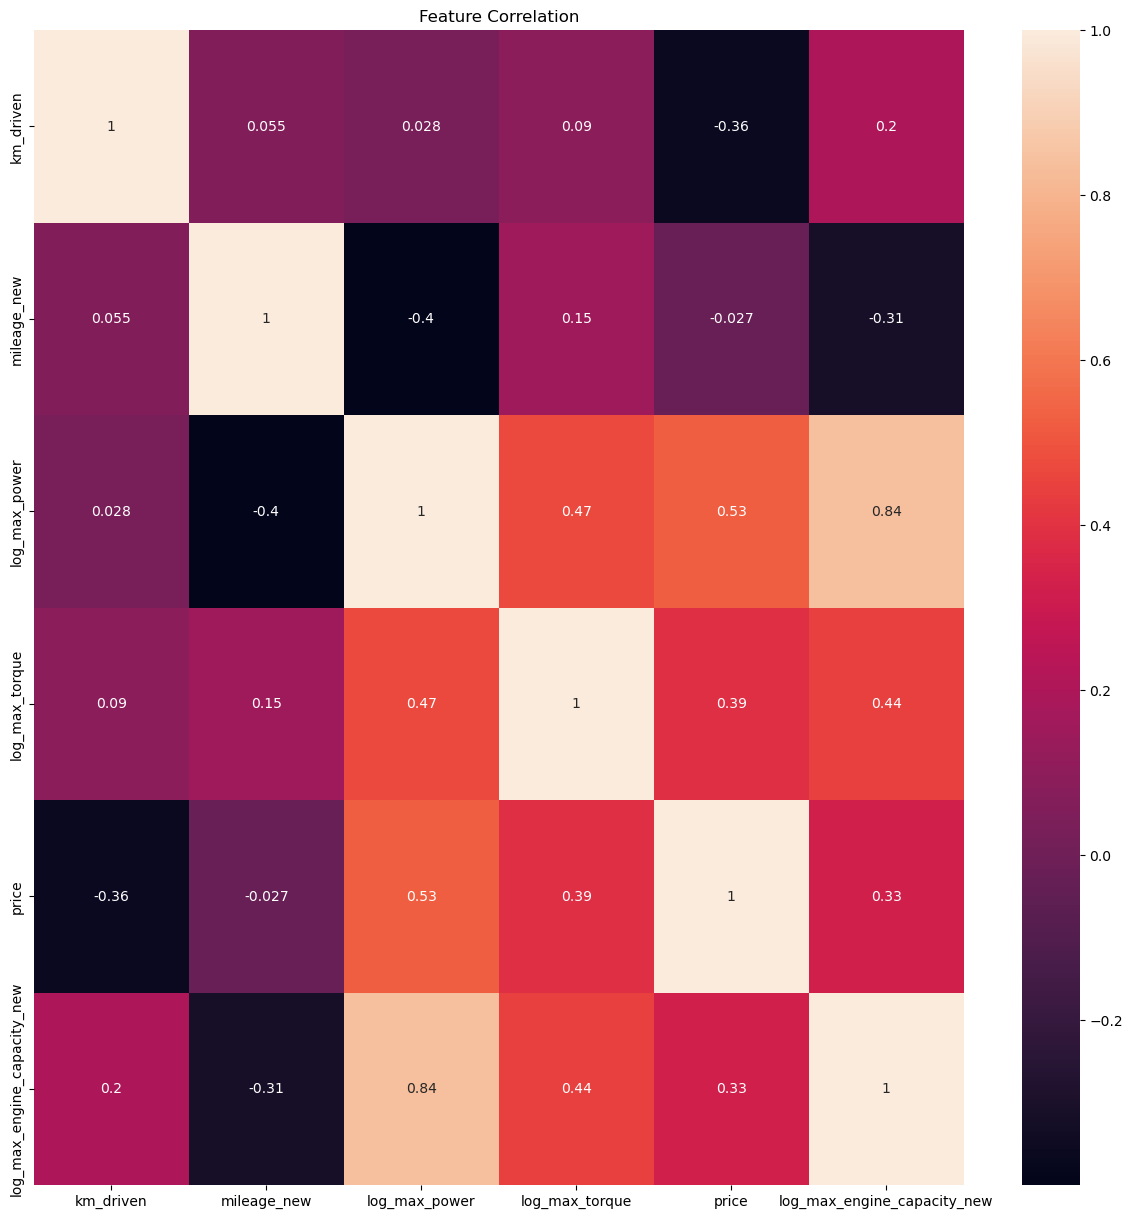

In [11]:
# Plot histograms and correlation heatmap for all numerical features
import matplotlib.pyplot as plt
import seaborn as sns
import math

plt.figure(figsize=(15, 15))

sns.heatmap(df[[
"km_driven", "mileage_new", 
    "log_max_power", "log_max_torque", "price",
 "log_max_engine_capacity_new"
]].corr(), annot=True)
plt.title("Feature Correlation")
plt.show()

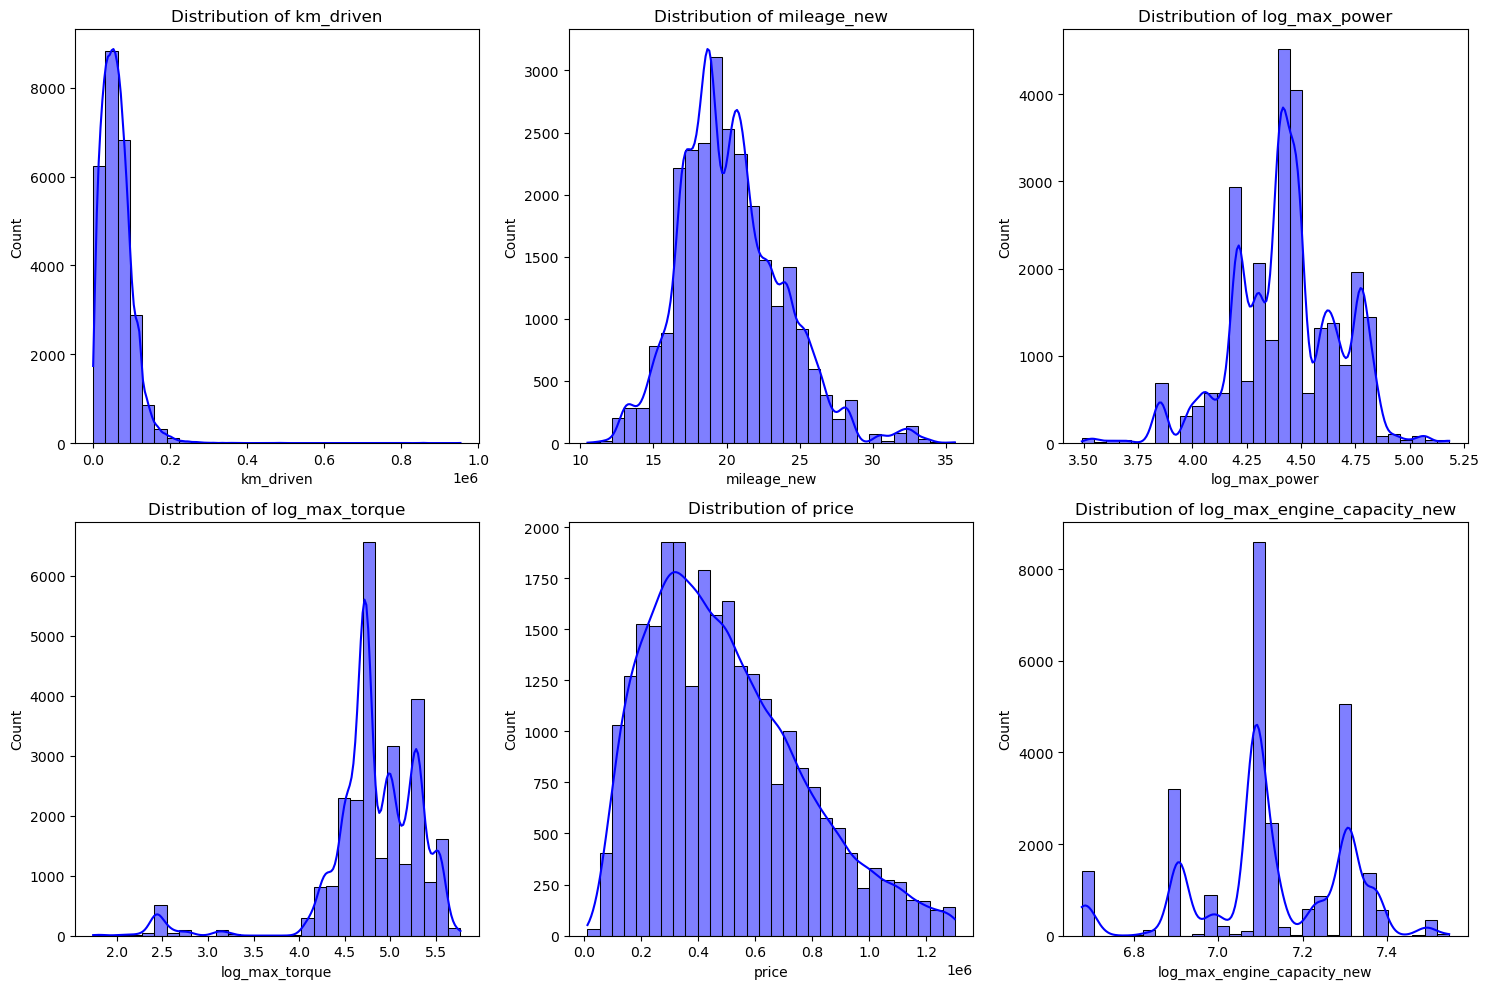

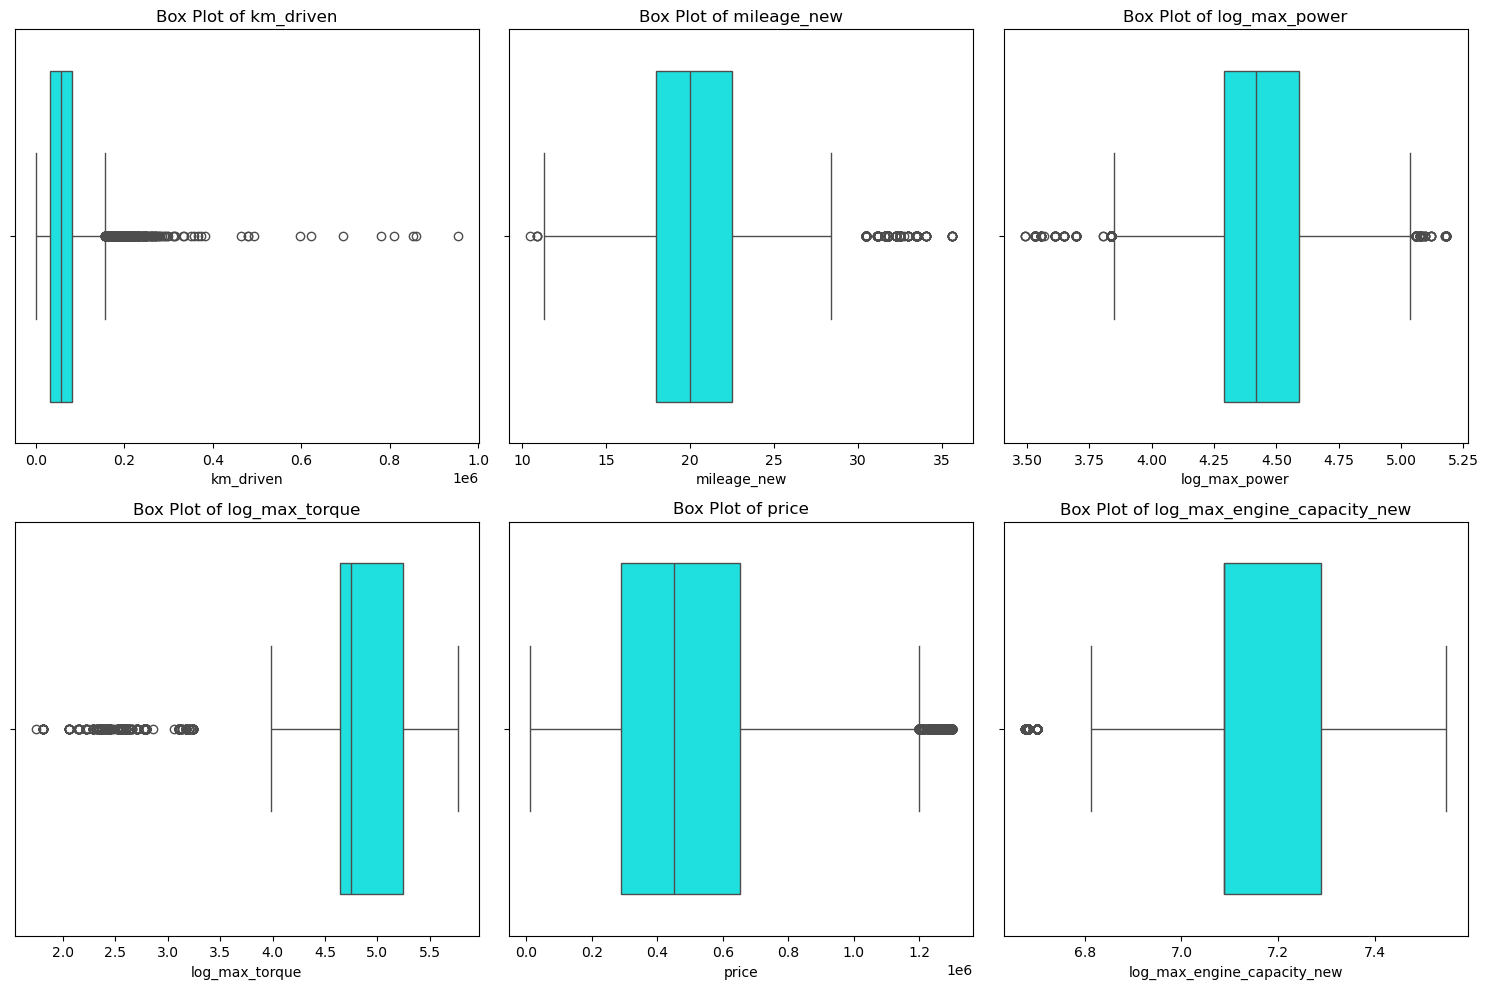

In [12]:
# Plot histograms and correlation heatmap for all numerical features
import matplotlib.pyplot as plt
import seaborn as sns
import math

# Select all numerical columns (including int, float, bool)
# Change the numerical_columns assignment to use the specified columns from df
numerical_columns = [
    "km_driven", "mileage_new",
    "log_max_power", "log_max_torque", "price",
    "log_max_engine_capacity_new"
]

# --- HISTOGRAMS ---
n_cols = 3
n_rows = math.ceil(len(numerical_columns) / n_cols)
plt.figure(figsize=(15, 5 * n_rows))
for i, feature in enumerate(numerical_columns, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.histplot(df[feature], kde=True, bins=30, color='blue')
    plt.title(f'Distribution of {feature}')
plt.tight_layout()
plt.show()

# Create box plots
plt.figure(figsize=(15, 5 * n_rows))
for i, feature in enumerate(numerical_columns, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.boxplot(x=df[feature], color='cyan')
    plt.title(f'Box Plot of {feature}')
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

# Define neuron configurations (4 different numbers of neurons)
neuron_no = [32, 64, 128, 256]  # Neurons
layer_no = [1, 2, 3, 4]  # Number of hidden layers

mse_train = {layers: [] for layers in layer_no}  # Store training MSE for each layer configuration
mse_val = {layers: [] for layers in layer_no}  # Store validation MSE for each layer configuration

# Loop over different numbers of hidden layers (1, 2, 3, 4 layers)
for layers in layer_no:
    for neurons in neuron_no:
        print(f"Testing model with {layers} hidden layers and {neurons} neurons")
        
        # Build the model with the specified number of hidden layers and neurons
        model = Sequential()
        model.add(Dense(neurons, activation='relu', input_shape=(X_train.shape[1],)))  # Input + 1st hidden layer
        for _ in range(layers - 1):  # Add additional hidden layers
            model.add(Dense(neurons, activation='relu'))
        model.add(Dense(1))  # Output layer for regression
        
        # Compile and train the model
        model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')
        history = model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=10, batch_size=32, verbose=0)

        # Store the MSE for both training and validation
        mse_train[layers].append(history.history['loss'][-1])  # Last epoch training MSE
        mse_val[layers].append(history.history['val_loss'][-1])  # Last epoch validation MSE
        print(f"Layers: {layers}, Neurons: {neurons}, Train MSE: {mse_train[layers][-1]:.2f}, Val MSE: {mse_val[layers][-1]:.2f}")

# Plot MSE for both training and validation for each configuration
plt.figure(figsize=(10, 8))

# Plot for each layer configuration
for layers in layer_no:
    plt.plot(neuron_no, mse_train[layers], marker='o', label=f'Train MSE - {layers} Layers', linestyle='-', color='blue')
    plt.plot(neuron_no, mse_val[layers], marker='o', label=f'Val MSE - {layers} Layers', linestyle='--', color='red')

plt.title("Training and Validation MSE for Varying Neurons and Hidden Layers")
plt.xlabel("Number of Neurons in Hidden Layer")
plt.ylabel("MSE")
plt.legend()
plt.grid(True)
plt.show()


In [14]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

model1 = Sequential([
    Dense(128, activation="relu", input_shape=(X_train.shape[1],)),
    Dropout(0.2),
    Dense(128, activation="relu"),
    Dropout(0.2),
    Dense(1)
])
model1.summary()
model1.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])

c:\Users\narut\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 128)            │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,537 (68.50 KB)

 Trainable params: 17,537 (68.50 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
history = model1.fit(X_train, y_train, epochs=70,validation_data=(X_val, y_val))

Epoch 1/70
654/654 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 316162539520.0000 - mae: 494456.4688 - val_loss: 299892310016.0000 - val_mae: 479357.4375
Epoch 2/70
654/654 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 291308371968.0000 - mae: 470294.6562 - val_loss: 235499995136.0000 - val_mae: 411134.5938
Epoch 3/70
654/654 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 211245023232.0000 - mae: 381484.8750 - val_loss: 113916796928.0000 - val_mae: 256287.2812
Epoch 4/70
654/654 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 88416141312.0000 - mae: 222855.4688 - val_loss: 47887175680.0000 - val_mae: 177027.2656
Epoch 5/70
654/654 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 49193160704.0000 - mae: 178981.7188 - val_loss: 44313071616.0000 - val_mae: 171137.2188
Epoch 6/70
654/654 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 45006180352.0000 - mae: 172345.2969 - val_loss: 40624254976.0000 - val_mae: 163812.9062
Epoch 7/70
654/654 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 41213210624.0000 - mae: 164567.6406 - val_loss

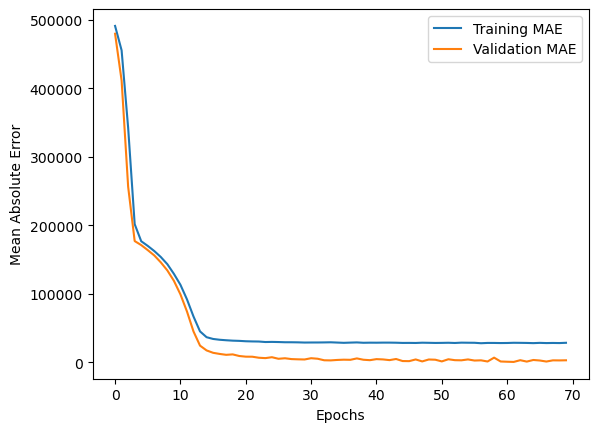

In [16]:
import matplotlib.pyplot as plt
# Plot training history
plt.plot(history.history['mae'], label='Training MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.xlabel('Epochs')
plt.ylabel('Mean Absolute Error')
plt.legend()
plt.show()

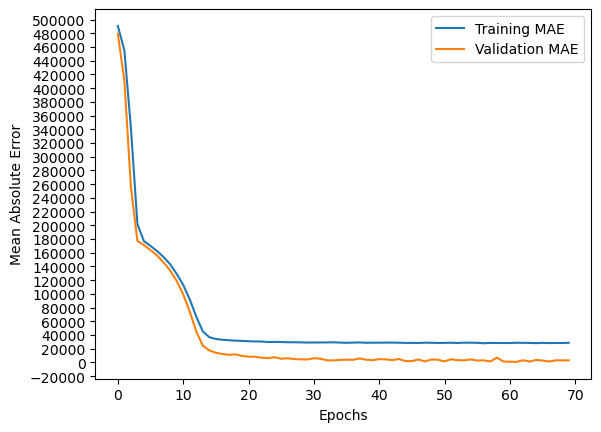

In [17]:
import matplotlib.pyplot as plt

plt.plot(history.history['mae'], label='Training MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.xlabel('Epochs')
plt.ylabel('Mean Absolute Error')
plt.legend()

# Add more y-axis ticks for detail
plt.locator_params(axis='y', nbins=30)  # Increase nbins for more ticks

plt.show()

In [18]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

model2 = Sequential([
    Dense(128, activation="relu", input_shape=(X_train.shape[1],)),
    Dropout(0.2),
    Dense(128, activation="relu"),
    Dropout(0.2),
    Dense(1)
])
model2.summary()
model2.compile(optimizer="adam", loss="mse", metrics=["mae"])

c:\Users\narut\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 128)            │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,537 (68.50 KB)

 Trainable params: 17,537 (68.50 KB)

 Non-trainable params: 0 (0.00 B)

In [19]:
history = model2.fit(X_train, y_train, epochs=70,validation_data=(X_val, y_val))

Epoch 1/70
654/654 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 314571685888.0000 - mae: 492797.9375 - val_loss: 258948448256.0000 - val_mae: 437132.0625
Epoch 2/70
654/654 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 216297390080.0000 - mae: 387924.8438 - val_loss: 83942023168.0000 - val_mae: 216311.0781
Epoch 3/70
654/654 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 67528867840.0000 - mae: 195126.6094 - val_loss: 47290068992.0000 - val_mae: 175521.7969
Epoch 4/70
654/654 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 47742447616.0000 - mae: 176839.7344 - val_loss: 44688470016.0000 - val_mae: 171811.5469
Epoch 5/70
654/654 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 45801795584.0000 - mae: 173931.6406 - val_loss: 41892405248.0000 - val_mae: 166653.8281
Epoch 6/70
654/654 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 42249519104.0000 - mae: 166072.9844 - val_loss: 38720438272.0000 - val_mae: 160217.6719
Epoch 7/70
654/654 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 39290986496.0000 - mae: 160442.2969 - val_loss: 3

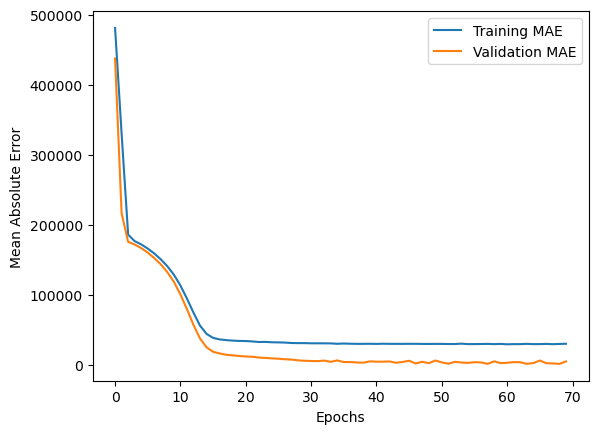

In [20]:
import matplotlib.pyplot as plt
# Plot training history
plt.plot(history.history['mae'], label='Training MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.xlabel('Epochs')
plt.ylabel('Mean Absolute Error')
plt.legend()
plt.show()

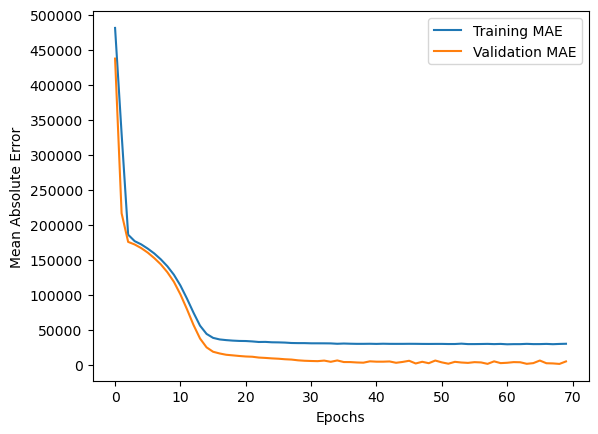

In [21]:
import matplotlib.pyplot as plt

plt.plot(history.history['mae'], label='Training MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.xlabel('Epochs')
plt.ylabel('Mean Absolute Error')
plt.legend()

# Add more y-axis ticks for detail
plt.locator_params(axis='y', nbins=20)  # Increase nbins for more ticks

plt.show()

In [22]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

model3 = Sequential([
    Dense(128, activation="relu", input_shape=(X_train.shape[1],)),
    Dropout(0.2),
    Dense(128, activation="relu"),
    Dropout(0.2),
    Dense(64, activation="relu"),
    Dropout(0.1),

    Dense(1)
])
model3.summary()
model3.compile(optimizer="adam", loss="mse", metrics=["mae"])

c:\Users\narut\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 128)            │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,729 (100.50 KB)

 Trainable params: 25,729 (100.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/70


654/654 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 256878575616.0000 - mae: 426407.8750 - val_loss: 43491586048.0000 - val_mae: 168692.8594
Epoch 2/70
654/654 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 42104340480.0000 - mae: 166674.1875 - val_loss: 28477196288.0000 - val_mae: 137521.8125
Epoch 3/70
654/654 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 25476378624.0000 - mae: 128556.1406 - val_loss: 7605985792.0000 - val_mae: 69785.1641
Epoch 4/70
654/654 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 7311274496.0000 - mae: 66374.5000 - val_loss: 879204672.0000 - val_mae: 22667.6328
Epoch 5/70
654/654 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 3337074944.0000 - mae: 43804.7500 - val_loss: 471777120.0000 - val_mae: 15718.8965
Epoch 6/70
654/654 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 2958942720.0000 - mae: 40155.3945 - val_loss: 365969888.0000 - val_mae: 13749.8154
Epoch 7/70
654/654 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 2688665088.0000 - mae: 37939.5938 - val_loss: 218570592.0000 - val_mae: 10665.1

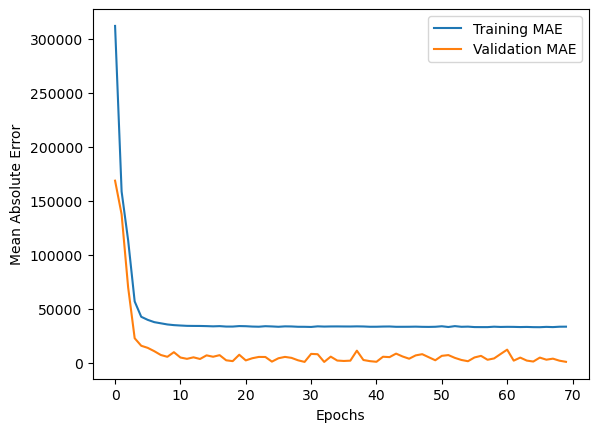

In [23]:
history = model3.fit(X_train, y_train, epochs=70,validation_data=(X_val, y_val))
import matplotlib.pyplot as plt
# Plot training history
plt.plot(history.history['mae'], label='Training MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.xlabel('Epochs')
plt.ylabel('Mean Absolute Error')
plt.legend()
plt.show()

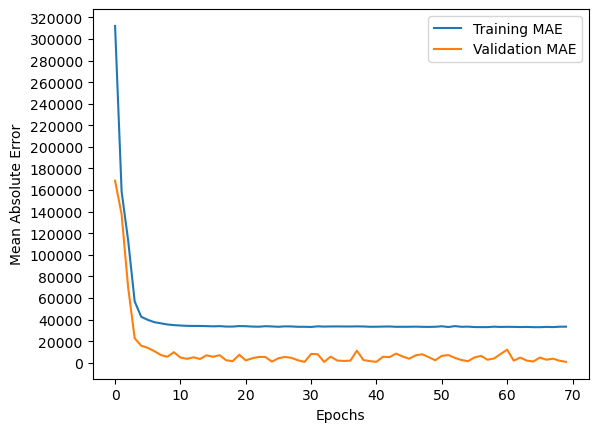

In [24]:
import matplotlib.pyplot as plt

plt.plot(history.history['mae'], label='Training MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.xlabel('Epochs')
plt.ylabel('Mean Absolute Error')
plt.legend()

# Add more y-axis ticks for detail
plt.locator_params(axis='y', nbins=20)  # Increase nbins for more ticks

plt.show()

In [25]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

model4 = Sequential([
    Dense(512, activation="relu", input_shape=(X_train.shape[1],)),
    Dropout(0.2),
    Dense(256, activation="relu"),
    Dropout(0.2),
    Dense(127, activation="relu"),
    Dropout(0.1),
    Dense(64, activation="relu"),
    Dropout(0.1),
    Dense(1)
])
model4.summary()
model4.compile(optimizer="adam", loss="mse", metrics=["mae"])

c:\Users\narut\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_13 (Dense)                │ (None, 512)            │         3,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 127)            │        32,639 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 127)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 64)             │         8,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 175,808 (686.75 KB)

 Trainable params: 175,808 (686.75 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/70
654/654 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 161945124864.0000 - mae: 309592.4375 - val_loss: 1885330816.0000 - val_mae: 34246.5938
Epoch 2/70
654/654 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 3190035968.0000 - mae: 42873.2891 - val_loss: 345525024.0000 - val_mae: 14632.8691
Epoch 3/70
654/654 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 2341619200.0000 - mae: 35039.2969 - val_loss: 122272096.0000 - val_mae: 9098.8213
Epoch 4/70
654/654 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 2159724032.0000 - mae: 33544.5547 - val_loss: 104344584.0000 - val_mae: 8215.0957
Epoch 5/70
654/654 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 2173252864.0000 - mae: 33132.6211 - val_loss: 26374936.0000 - val_mae: 4220.9761
Epoch 6/70
654/654 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 2089557888.0000 - mae: 32553.4062 - val_loss: 75543280.0000 - val_mae: 7729.8394
Epoch 7/70
654/654 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 2117517824.0000 - mae: 32741.9746 - val_loss: 10266938.0000 - val_mae: 2650.4346
Epo

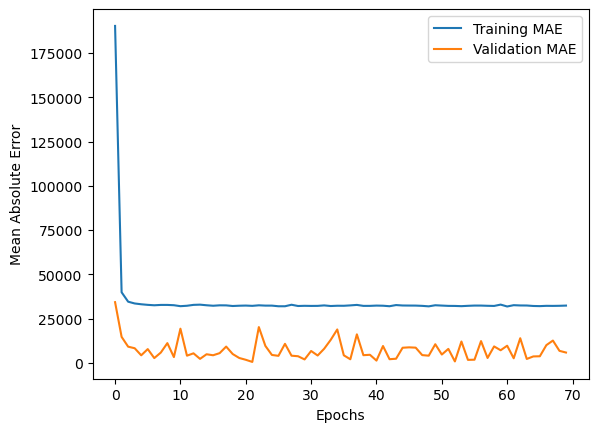

In [26]:
history = model4.fit(X_train, y_train, epochs=70,validation_data=(X_val, y_val))
import matplotlib.pyplot as plt
# Plot training history
plt.plot(history.history['mae'], label='Training MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.xlabel('Epochs')
plt.ylabel('Mean Absolute Error')
plt.legend()
plt.show()

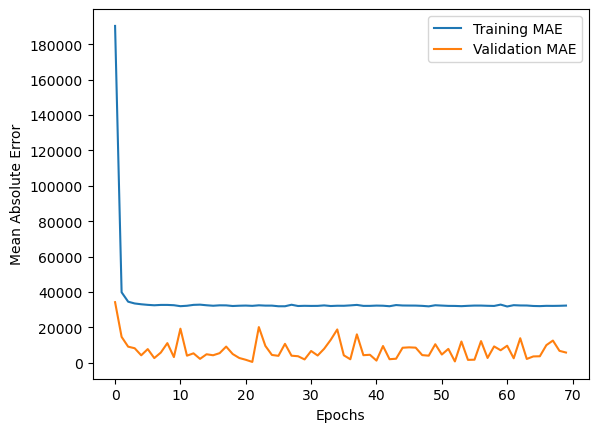

In [27]:
import matplotlib.pyplot as plt

plt.plot(history.history['mae'], label='Training MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.xlabel('Epochs')
plt.ylabel('Mean Absolute Error')
plt.legend()

# Add more y-axis ticks for detail
plt.locator_params(axis='y', nbins=20)  # Increase nbins for more ticks

plt.show()

In [28]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

model5 = Sequential([
    Dense(128, activation="relu", input_shape=(X_train.shape[1],)),
    Dropout(0.2),
    Dense(128, activation="relu"),
    Dropout(0.2),
    Dense(256, activation="relu"),
    Dropout(0.3),
    Dense(256, activation="relu"),
    Dropout(0.3),
    Dense(1)
])
model5.summary()
model5.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])

c:\Users\narut\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_18 (Dense)                │ (None, 128)            │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 116,481 (455.00 KB)

 Trainable params: 116,481 (455.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/70
654/654 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 155072741376.0000 - mae: 302002.0312 - val_loss: 1248400512.0000 - val_mae: 27963.2676
Epoch 2/70
654/654 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 3802861312.0000 - mae: 45761.2500 - val_loss: 415439424.0000 - val_mae: 17564.6191
Epoch 3/70
654/654 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 3230235136.0000 - mae: 40689.8516 - val_loss: 47409024.0000 - val_mae: 5127.8311
Epoch 4/70
654/654 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 3111220736.0000 - mae: 39627.9688 - val_loss: 120686312.0000 - val_mae: 9843.7891
Epoch 5/70
654/654 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 3129704960.0000 - mae: 39231.1328 - val_loss: 893605632.0000 - val_mae: 27652.3848
Epoch 6/70
654/654 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 3095969280.0000 - mae: 39555.5078 - val_loss: 916176256.0000 - val_mae: 29226.0508
Epoch 7/70
654/654 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 2962782464.0000 - mae: 38438.6797 - val_loss: 2037820928.0000 - val_mae: 42941.65

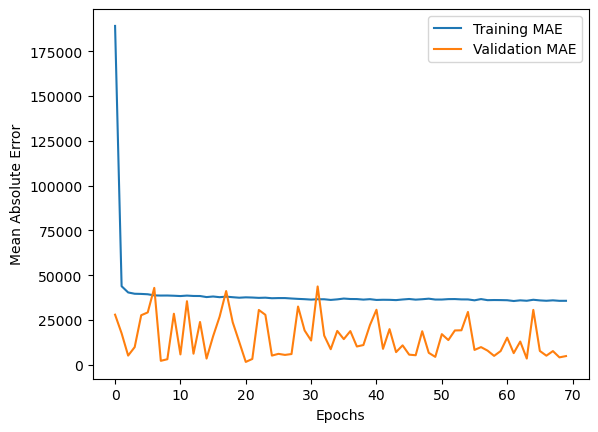

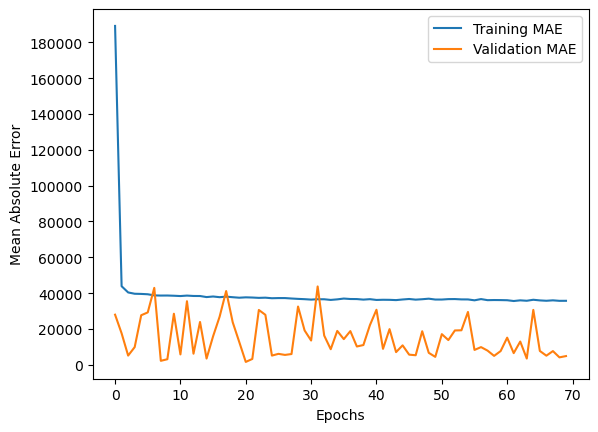

In [29]:

history = model5.fit(X_train, y_train, epochs=70,validation_data=(X_val, y_val))
import matplotlib.pyplot as plt
# Plot training history
plt.plot(history.history['mae'], label='Training MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.xlabel('Epochs')
plt.ylabel('Mean Absolute Error')
plt.legend()
plt.show()
import matplotlib.pyplot as plt

plt.plot(history.history['mae'], label='Training MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.xlabel('Epochs')
plt.ylabel('Mean Absolute Error')
plt.legend()

# Add more y-axis ticks for detail
plt.locator_params(axis='y', nbins=20)  # Increase nbins for more ticks

plt.show()

In [30]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

model6 = Sequential([
    Dense(128, activation="relu", input_shape=(X_train.shape[1],)),
    Dropout(0.2),
    Dense(128, activation="relu"),
    Dropout(0.2),
    Dense(128, activation="relu"),
    Dropout(0.2),
    Dense(1)
])
model6.summary()
model6.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])

c:\Users\narut\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_23 (Dense)                │ (None, 128)            │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,049 (133.00 KB)

 Trainable params: 34,049 (133.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/70
654/654 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 283172470784.0000 - mae: 457310.5312 - val_loss: 46481416192.0000 - val_mae: 174478.1406
Epoch 2/70
654/654 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 44631474176.0000 - mae: 170503.2812 - val_loss: 30304708608.0000 - val_mae: 141685.7188
Epoch 3/70
654/654 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 26276786176.0000 - mae: 130649.9453 - val_loss: 3769833472.0000 - val_mae: 49256.5273
Epoch 4/70
654/654 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4164770816.0000 - mae: 48882.0547 - val_loss: 330707584.0000 - val_mae: 13658.5977
Epoch 5/70
654/654 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 2890529536.0000 - mae: 38892.3398 - val_loss: 226954304.0000 - val_mae: 11564.3750
Epoch 6/70
654/654 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 2598441728.0000 - mae: 36739.9336 - val_loss: 215422048.0000 - val_mae: 12187.0303
Epoch 7/70
654/654 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 2541730048.0000 - mae: 35737.0938 - val_loss: 44809020.0000 - val_ma

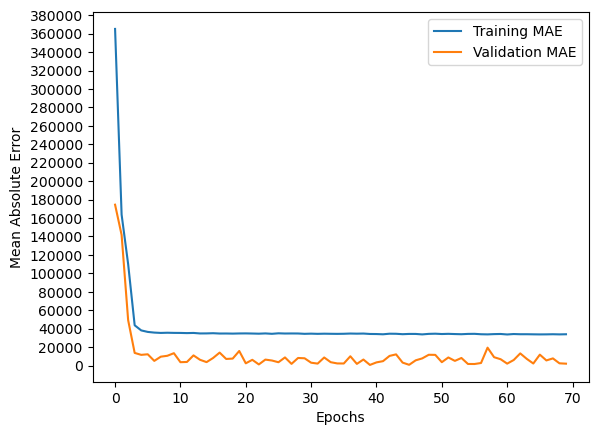

In [31]:
history = model6.fit(X_train, y_train, epochs=70,validation_data=(X_val, y_val))
import matplotlib.pyplot as plt

plt.plot(history.history['mae'], label='Training MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.xlabel('Epochs')
plt.ylabel('Mean Absolute Error')
plt.legend()

# Add more y-axis ticks for detail
plt.locator_params(axis='y', nbins=30)  # Increase nbins for more ticks

plt.show()

In [32]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

model6 = Sequential([
    Dense(128, activation="relu", input_shape=(X_train.shape[1],)),
    Dropout(0.1),
    Dense(128, activation="relu"),
    Dropout(0.1),
    Dense(128, activation="relu"),
    Dropout(0.2),
    Dense(1)
])
model6.summary()
model6.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])


c:\Users\narut\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_27 (Dense)                │ (None, 128)            │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_21 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,049 (133.00 KB)

 Trainable params: 34,049 (133.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/70
654/654 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 282383482880.0000 - mae: 458240.3750 - val_loss: 47477227520.0000 - val_mae: 176054.0938
Epoch 2/70
654/654 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 45224034304.0000 - mae: 172446.5469 - val_loss: 30599751680.0000 - val_mae: 142091.4531
Epoch 3/70
654/654 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 26035593216.0000 - mae: 129510.4375 - val_loss: 3202135296.0000 - val_mae: 45321.3047
Epoch 4/70
654/654 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 3145145600.0000 - mae: 42858.7344 - val_loss: 313440288.0000 - val_mae: 13025.3682
Epoch 5/70
654/654 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 2056877056.0000 - mae: 33205.3906 - val_loss: 144754160.0000 - val_mae: 9239.8994
Epoch 6/70
654/654 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1885236864.0000 - mae: 31412.1562 - val_loss: 59310124.0000 - val_mae: 5637.0947
Epoch 7/70
654/654 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1905277312.0000 - mae: 30774.1992 - val_loss: 162422912.0000 - val_mae:

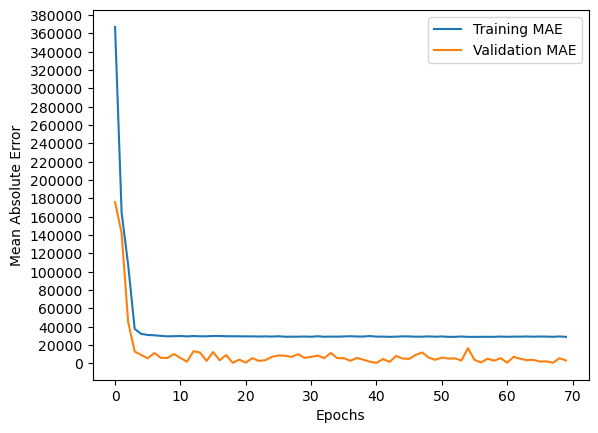

In [33]:
history = model6.fit(X_train, y_train, epochs=70,validation_data=(X_val, y_val))
import matplotlib.pyplot as plt

plt.plot(history.history['mae'], label='Training MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.xlabel('Epochs')
plt.ylabel('Mean Absolute Error')
plt.legend()

# Add more y-axis ticks for detail
plt.locator_params(axis='y', nbins=30)  # Increase nbins for more ticks

plt.show()

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

model7 = Sequential([
    Dense(128, activation="relu", input_shape=(X_train.shape[1],)),
    Dropout(0.1),
    Dense(128, activation="relu"),
    Dropout(0.1),
    Dense(1)
])
model7.summary()
model7.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])
history = model7.fit(X_train, y_train, epochs=10,validation_data=(X_val, y_val))

import matplotlib.pyplot as plt

plt.plot(history.history['mae'], label='Training MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.xlabel('Epochs')
plt.ylabel('Mean Absolute Error')
plt.legend()

# Add more y-axis ticks for detail
plt.locator_params(axis='y', nbins=30)  # Increase nbins for more ticks

plt.show()


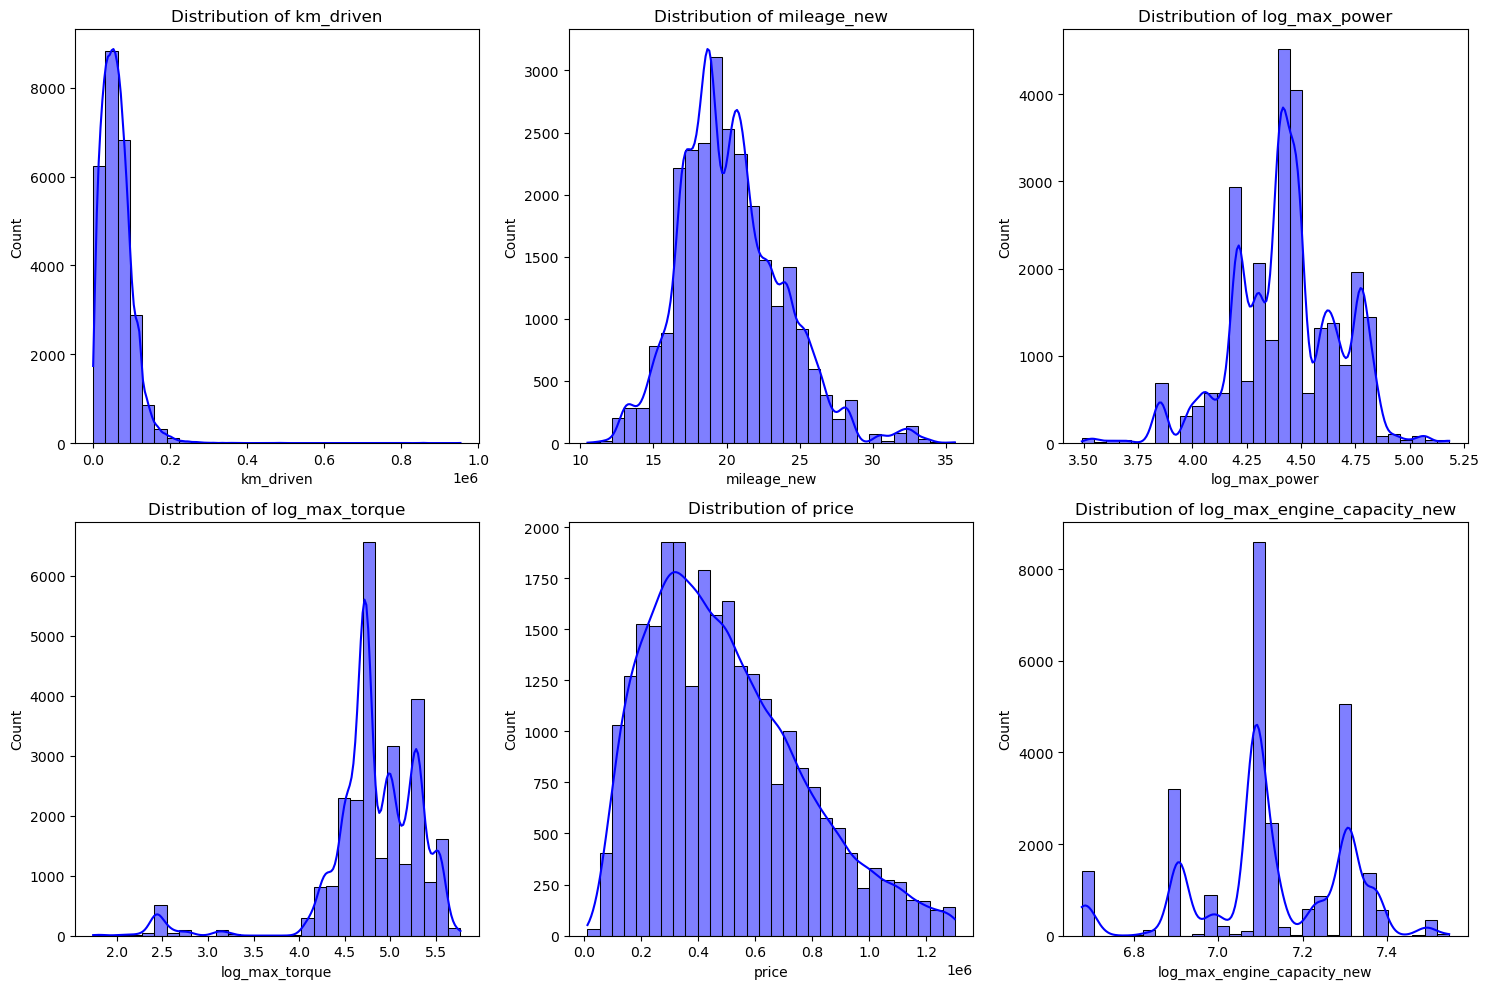

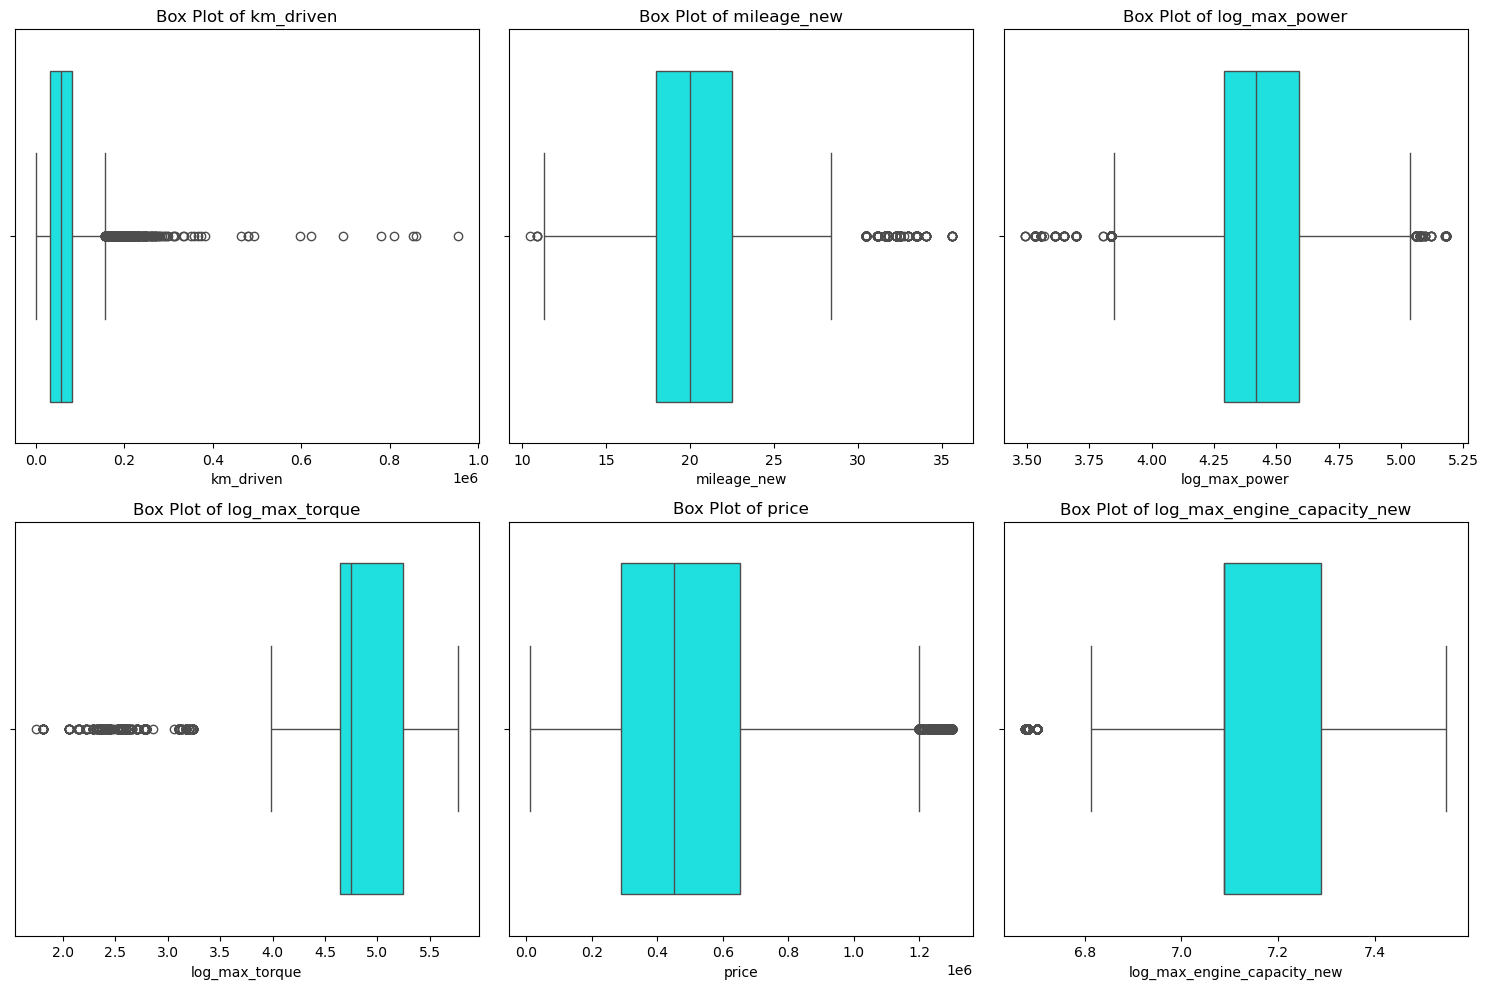

In [34]:
# Change the numerical_columns assignment to use the specified columns from df
numerical_columns = [
    "km_driven", "mileage_new",
    "log_max_power", "log_max_torque", "price",
    "log_max_engine_capacity_new"
]



# --- HISTOGRAMS ---
n_cols = 3
n_rows = math.ceil(len(numerical_columns) / n_cols)
plt.figure(figsize=(15, 5 * n_rows))
for i, feature in enumerate(numerical_columns, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.histplot(df[feature], kde=True, bins=30, color='blue')
    plt.title(f'Distribution of {feature}')
plt.tight_layout()
plt.show()

# Create box plots
plt.figure(figsize=(15, 5 * n_rows))
for i, feature in enumerate(numerical_columns, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.boxplot(x=df[feature], color='cyan')
    plt.title(f'Box Plot of {feature}')
plt.tight_layout()
plt.show()